# Commodity Bubble Detection -- ML Pipeline

Classifies commodity metal price bubbles using three ML models with proper **time-series cross-validation**.

**Key corrections** over the original R pipeline:
- Time-series CV (expanding window) instead of random k-fold -- prevents future data leakage
- Consistent class imbalance handling (balanced weights) across all models
- Identical feature set for all three models -- fair comparison
- Early stopping for LightGBM

**Ground truth:** GSADF bubble labels from full-sample detection (treated as given).

**Models:** LASSO (linear benchmark) | Random Forest | LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import shap

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
os.makedirs('outputs', exist_ok=True)
print('All packages loaded.')

All packages loaded.


## 1. Load Data

Load `df_master` generated by `R/metals30_data_prep.R` (semicolon-separated, comma decimal).

In [2]:
df_master = pd.read_csv('../R/df_master.csv', sep=';', decimal=',', index_col=0)
df_master['Date'] = pd.to_datetime(df_master['Date'])
df_master = df_master.sort_values('Date').reset_index(drop=True)

bubble_cols = [c for c in df_master.columns if c.endswith('_BD')]
numeric_cols = [c for c in df_master.select_dtypes(include='number').columns
                if c not in bubble_cols]

print('Dataset: {} rows x {} columns'.format(df_master.shape[0], df_master.shape[1]))
print('Period:  {} to {}'.format(df_master['Date'].min().date(), df_master['Date'].max().date()))
print()
print('Metals:       ', [c for c in numeric_cols if c in ['CODALY','CUDALY','LIDALY','NIDALY']])
print('Macro/Market: ', [c for c in numeric_cols if c not in ['CODALY','CUDALY','LIDALY','NIDALY']])
print()
print('Bubble prevalence:')
for col in bubble_cols:
    n = int(df_master[col].sum())
    pct = 100.0 * n / len(df_master)
    metal = col.replace('_BD', '')
    print('  {:8s}: {:4d} days ({:.1f}%)'.format(metal, n, pct))

Dataset: 2152 rows x 21 columns
Period:  2017-05-10 to 2025-10-31

Metals:        ['CODALY', 'CUDALY', 'LIDALY', 'NIDALY']
Macro/Market:  ['OIL_WTI', 'GAS_HHUB', 'USD_INDEX', 'VIX', 'YIELD_10Y', 'GOLD_FUT', 'MSCI_ETF', 'MSCI_EM', 'SP500', 'QCLN', 'C_CHR', 'C_US']

Bubble prevalence:
  CODALY  :  230 days (10.7%)
  CUDALY  :   39 days (1.8%)
  LIDALY  : 1089 days (50.6%)
  NIDALY  :   26 days (1.2%)


## 2. Bubble Periods

Price series with GSADF-detected bubble episodes shaded in purple.

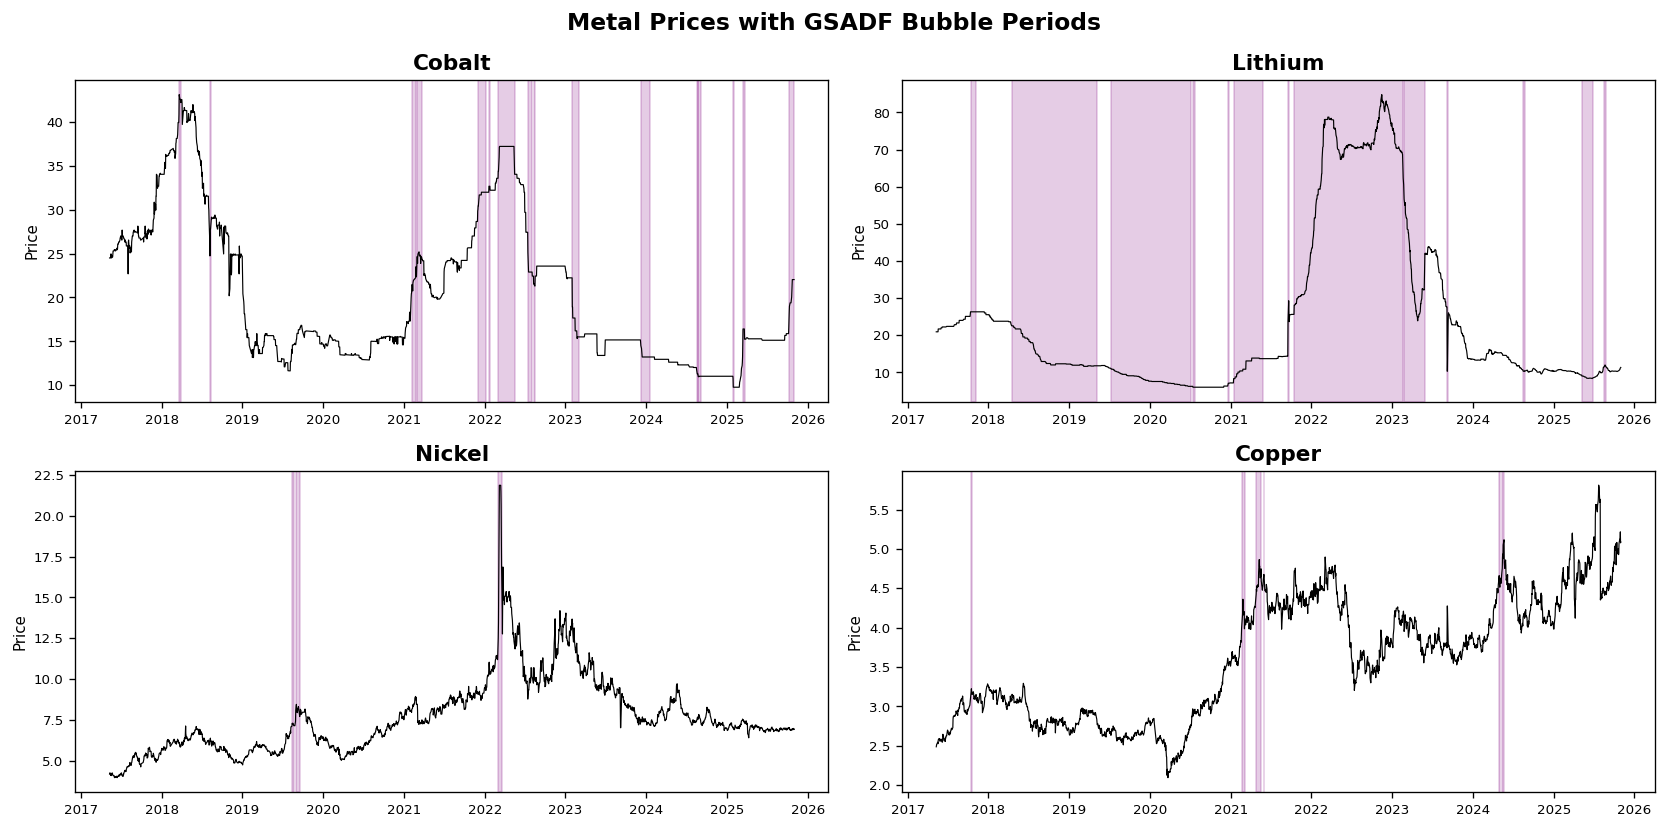

In [3]:
metal_map = {
    'Cobalt':  ('CODALY', 'CODALY_BD'),
    'Lithium': ('LIDALY', 'LIDALY_BD'),
    'Nickel':  ('NIDALY', 'NIDALY_BD'),
    'Copper':  ('CUDALY', 'CUDALY_BD'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for idx, (metal, (pcol, dcol)) in enumerate(metal_map.items()):
    ax = axes.flat[idx]
    dates = df_master['Date']
    ax.plot(dates, df_master[pcol], color='black', lw=0.7)
    
    # Shade bubble periods
    bub = df_master[dcol].values
    in_b = False
    for i in range(len(bub)):
        if bub[i] == 1 and not in_b:
            start = dates.iloc[i]
            in_b = True
        elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
            ax.axvspan(start, dates.iloc[i], color='purple', alpha=0.2)
            in_b = False
    
    ax.set_title(metal, fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.set_ylabel('Price', fontsize=9)

plt.suptitle('Metal Prices with GSADF Bubble Periods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/bubble_timelines.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 3. Feature Engineering

For each metal, build a feature matrix with:
- **Log-returns** and **10-day rolling volatility** for every numeric series (including VIX)
- **Lagged price levels** for macro/market variables
- **Peer bubble dummies** (other metals' bubble flags)
- Everything **lagged by 1 day** to prevent look-ahead bias


In [4]:
def prepare_ml_data(target_col, df_master):
    '''Build lagged feature matrix for bubble classification.'''
    target_dummy = target_col + '_BD'
    bubble_cols = [c for c in df_master.columns if c.endswith('_BD')]
    num_cols = [c for c in df_master.select_dtypes(include='number').columns
                if c not in bubble_cols]
    peer_dummies = [c for c in bubble_cols if c != target_dummy]

    df = df_master[['Date'] + num_cols + bubble_cols].copy()
    df = df.sort_values('Date').reset_index(drop=True)

    # Log-returns and 10-day rolling volatility
    for col in num_cols:
        safe = df[col].clip(lower=0.001)
        lr = np.log(safe).diff()
        df[col + '_Ret'] = lr
        df[col + '_Vol'] = lr.rolling(10).std()

    # Lag ALL features by 1 day
    lagged = {}
    for c in [c for c in df.columns if c.endswith('_Ret')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in [c for c in df.columns if c.endswith('_Vol')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in num_cols:
        lagged[c + '_Level_Lag1'] = df[c].shift(1)
    for c in peer_dummies:
        lagged[c + '_Lag1'] = df[c].shift(1).fillna(0)

    df_out = pd.DataFrame(lagged, index=df.index)
    df_out['Date'] = df['Date']
    df_out['Target'] = df[target_dummy].astype(int)
    return df_out.dropna().reset_index(drop=True)

# Quick test
df_test = prepare_ml_data('CODALY', df_master)
feats = [c for c in df_test.columns if c not in ['Date', 'Target']]
print('Features: {} | Rows: {} | Bubble days: {}'.format(
    len(feats), len(df_test), df_test['Target'].sum()))

Features: 51 | Rows: 2141 | Bubble days: 230


## 4. Evaluation Framework

**Expanding-window time-series CV** (5 splits). Each fold trains on all data up to a cutpoint,
then tests on the next chronological block. The model never sees future data during training.

All models use **balanced class weights** to handle the rarity of bubble events.

In [5]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    '''Compute classification metrics from predicted probabilities.'''
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
    return {
        'Bal. Accuracy': round((sens + spec) / 2, 3),
        'Sensitivity': round(sens, 3),
        'Specificity': round(spec, 3),
        'Precision': round(prec, 3),
        'AUC': round(auc, 3),
        'Bubbles': '{}/{}'.format(tp, tp + fn)
    }


def run_timeseries_cv(X, y, model_fn, n_splits=5, scale=False):
    '''Expanding-window time-series CV. Training always precedes testing.'''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_preds, all_true = [], []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if y_tr.sum() < 5:
            continue
        if scale:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        model = model_fn()
        model.fit(X_tr, y_tr)
        all_preds.append(model.predict_proba(X_te)[:, 1])
        all_true.append(y_te)

    return np.concatenate(all_preds), np.concatenate(all_true)


# Storage
cv_preds = {}  # (metal, model_name) -> (y_true, y_prob)
metal_configs = {
    'Cobalt': 'CODALY', 'Lithium': 'LIDALY',
    'Nickel': 'NIDALY', 'Copper': 'CUDALY'
}
print('CV framework ready: expanding-window splits (no future leakage).')

CV framework ready: expanding-window splits (no future leakage).


## 5. LASSO (Linear Benchmark)

L1-penalized logistic regression. Automatically selects features by shrinking weak predictors to zero.
Uses `class_weight='balanced'` and features are standardized per fold.

In [6]:
results_lasso = {}
lasso_models = {}

def make_lasso():
    return LogisticRegression(
        penalty='l1', solver='saga', C=1.0,
        class_weight='balanced', max_iter=10000, random_state=42)

print('LASSO (L1-Penalized Logistic Regression)')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print('  {}: skipped (too few bubbles)'.format(metal))
        continue

    preds, true = run_timeseries_cv(X, y, make_lasso, n_splits=5, scale=True)
    metrics = compute_metrics(true, preds)
    results_lasso[metal] = metrics
    cv_preds[(metal, 'LASSO')] = (true, preds)

    # Full model for coefficient analysis
    sc = StandardScaler()
    full_model = make_lasso()
    full_model.fit(sc.fit_transform(X), y)
    lasso_models[metal] = {'model': full_model, 'features': feats, 'scaler': sc}

    n_nz = int(np.sum(full_model.coef_[0] != 0))
    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (non-zero: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], n_nz))

LASSO (L1-Penalized Logistic Regression)
  Cobalt: AUC=0.386  Bal.Acc=0.447  Bubbles=44/222  (non-zero: 47)
  Lithium: AUC=0.561  Bal.Acc=0.653  Bubbles=855/926  (non-zero: 49)
  Nickel: AUC=0.978  Bal.Acc=0.911  Bubbles=11/11  (non-zero: 30)
  Copper: AUC=0.505  Bal.Acc=0.411  Bubbles=0/9  (non-zero: 43)


## 6. Random Forest

Ensemble of 500 decision trees with `class_weight='balanced'`.
Each tree is trained on a bootstrap sample; the ensemble averages their votes.

In [7]:
results_rf = {}
rf_models = {}

def make_rf():
    return RandomForestClassifier(
        n_estimators=500, class_weight='balanced',
        random_state=42, n_jobs=-1)

print('Random Forest (500 trees, balanced weights)')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print('  {}: skipped'.format(metal))
        continue

    preds, true = run_timeseries_cv(X, y, make_rf, n_splits=5)
    metrics = compute_metrics(true, preds)
    results_rf[metal] = metrics
    cv_preds[(metal, 'Random Forest')] = (true, preds)

    # Full model for feature importance
    full_model = make_rf()
    full_model.fit(X, y)
    rf_models[metal] = {'model': full_model, 'features': feats, 'X': X, 'y': y}

    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles']))

Random Forest (500 trees, balanced weights)
  Cobalt: AUC=0.511  Bal.Acc=0.500  Bubbles=0/222
  Lithium: AUC=0.489  Bal.Acc=0.581  Bubbles=759/926
  Nickel: AUC=0.667  Bal.Acc=0.500  Bubbles=0/11
  Copper: AUC=0.319  Bal.Acc=0.500  Bubbles=0/9


## 7. LightGBM

Gradient-boosted trees with `is_unbalance=True`. Uses **early stopping** (patience=50)
with a temporal validation set (last 20% of each training fold) to prevent overfitting.

In [8]:
results_lgbm = {}
lgbm_models = {}

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'is_unbalance': True,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbosity': -1,
    'seed': 42,
}

print('LightGBM (Gradient Boosting with early stopping)')
print('=' * 55)

for metal, col in metal_configs.items():
    df_ml = prepare_ml_data(col, df_master)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X, y = df_ml[feats].values, df_ml['Target'].values

    if y.sum() < 10:
        print('  {}: skipped'.format(metal))
        continue

    # Time-series CV with early stopping
    tscv = TimeSeriesSplit(n_splits=5)
    all_preds, all_true, best_iters = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if y_tr.sum() < 5:
            continue

        # Temporal validation: last 20% of training fold
        val_n = max(int(len(X_tr) * 0.2), 50)
        X_val, y_val = X_tr[-val_n:], y_tr[-val_n:]
        X_tr_inner, y_tr_inner = X_tr[:-val_n], y_tr[:-val_n]

        d_train = lgb.Dataset(X_tr_inner, y_tr_inner)
        d_val = lgb.Dataset(X_val, y_val, reference=d_train)

        bst = lgb.train(
            lgb_params, d_train, num_boost_round=500,
            valid_sets=[d_val],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

        all_preds.append(bst.predict(X_te))
        all_true.append(y_te)
        best_iters.append(bst.best_iteration)

    preds_arr = np.concatenate(all_preds)
    true_arr = np.concatenate(all_true)
    metrics = compute_metrics(true_arr, preds_arr)
    results_lgbm[metal] = metrics
    cv_preds[(metal, 'LightGBM')] = (true_arr, preds_arr)

    # Full model for SHAP
    d_full = lgb.Dataset(X, y)
    bst_full = lgb.train(lgb_params, d_full, num_boost_round=200)
    lgbm_models[metal] = {'model': bst_full, 'features': feats, 'X': X, 'y': y}

    avg_iter = int(np.mean(best_iters))
    print('  {}: AUC={:.3f}  Bal.Acc={:.3f}  Bubbles={}  (avg best iter: {})'.format(
        metal, metrics['AUC'], metrics['Bal. Accuracy'], metrics['Bubbles'], avg_iter))

LightGBM (Gradient Boosting with early stopping)
  Cobalt: AUC=0.666  Bal.Acc=0.513  Bubbles=9/222  (avg best iter: 16)
  Lithium: AUC=0.145  Bal.Acc=0.358  Bubbles=615/926  (avg best iter: 5)
  Nickel: AUC=0.122  Bal.Acc=0.473  Bubbles=0/11  (avg best iter: 15)
  Copper: AUC=0.751  Bal.Acc=0.481  Bubbles=0/9  (avg best iter: 1)


## 8. Results Comparison

  Metal         Model  Bal. Accuracy  Sensitivity  Specificity  Precision   AUC Bubbles
 Cobalt         LASSO          0.447        0.198        0.696      0.085 0.386  44/222
 Cobalt Random Forest          0.500        0.000        1.000      0.000 0.511   0/222
 Cobalt      LightGBM          0.513        0.041        0.985      0.273 0.666   9/222
Lithium         LASSO          0.653        0.923        0.383      0.619 0.561 855/926
Lithium Random Forest          0.581        0.820        0.342      0.575 0.489 759/926
Lithium      LightGBM          0.358        0.664        0.053      0.432 0.145 615/926
 Nickel         LASSO          0.911        1.000        0.822      0.042 0.978   11/11
 Nickel Random Forest          0.500        0.000        1.000      0.000 0.667    0/11
 Nickel      LightGBM          0.473        0.000        0.946      0.000 0.122    0/11
 Copper         LASSO          0.411        0.000        0.822      0.000 0.505     0/9
 Copper Random Forest          0

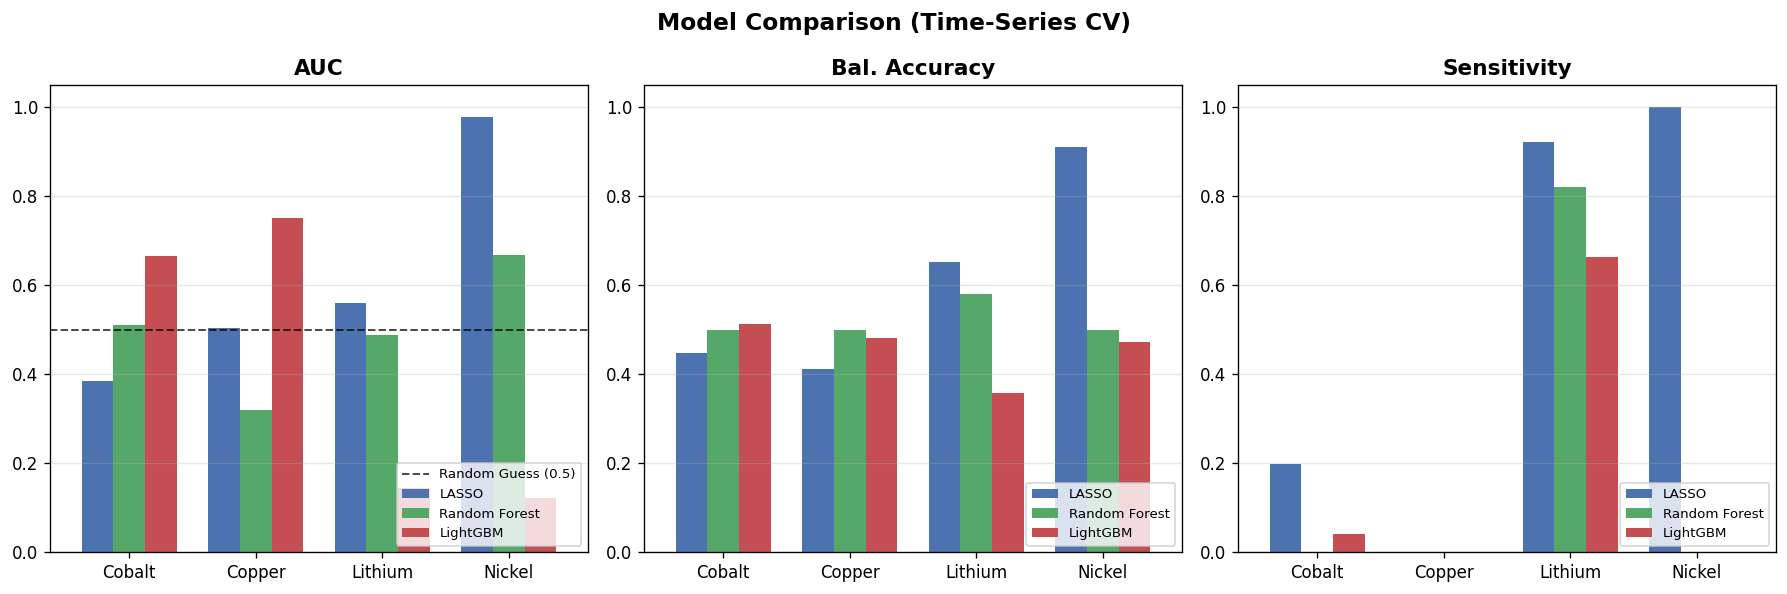

In [14]:
# Assemble results table
rows = []
for metal in metal_configs:
    for mname, res_dict in [('LASSO', results_lasso),
                             ('Random Forest', results_rf),
                             ('LightGBM', results_lgbm)]:
        if metal in res_dict:
            row = {'Metal': metal, 'Model': mname}
            row.update(res_dict[metal])
            rows.append(row)

df_results = pd.DataFrame(rows)
display_cols = ['Metal', 'Model', 'Bal. Accuracy', 'Sensitivity',
                'Specificity', 'Precision', 'AUC', 'Bubbles']
print(df_results[display_cols].to_string(index=False))
print()

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}

for i, metric in enumerate(['AUC', 'Bal. Accuracy', 'Sensitivity']):
    ax = axes[i]
    pivot = df_results.pivot(index='Metal', columns='Model', values=metric)
    pivot = pivot[['LASSO', 'Random Forest', 'LightGBM']]
    pivot.plot(kind='bar', ax=ax, rot=0,
              color=[colors[c] for c in pivot.columns], width=0.75)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    
    # Mark random guess baseline
    if metric == 'AUC':
        ax.axhline(0.5, color='black', lw=1.2, ls='--', alpha=0.7, label='Random Guess (0.5)')
        ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Model Comparison (Time-Series CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 9. ROC Curves

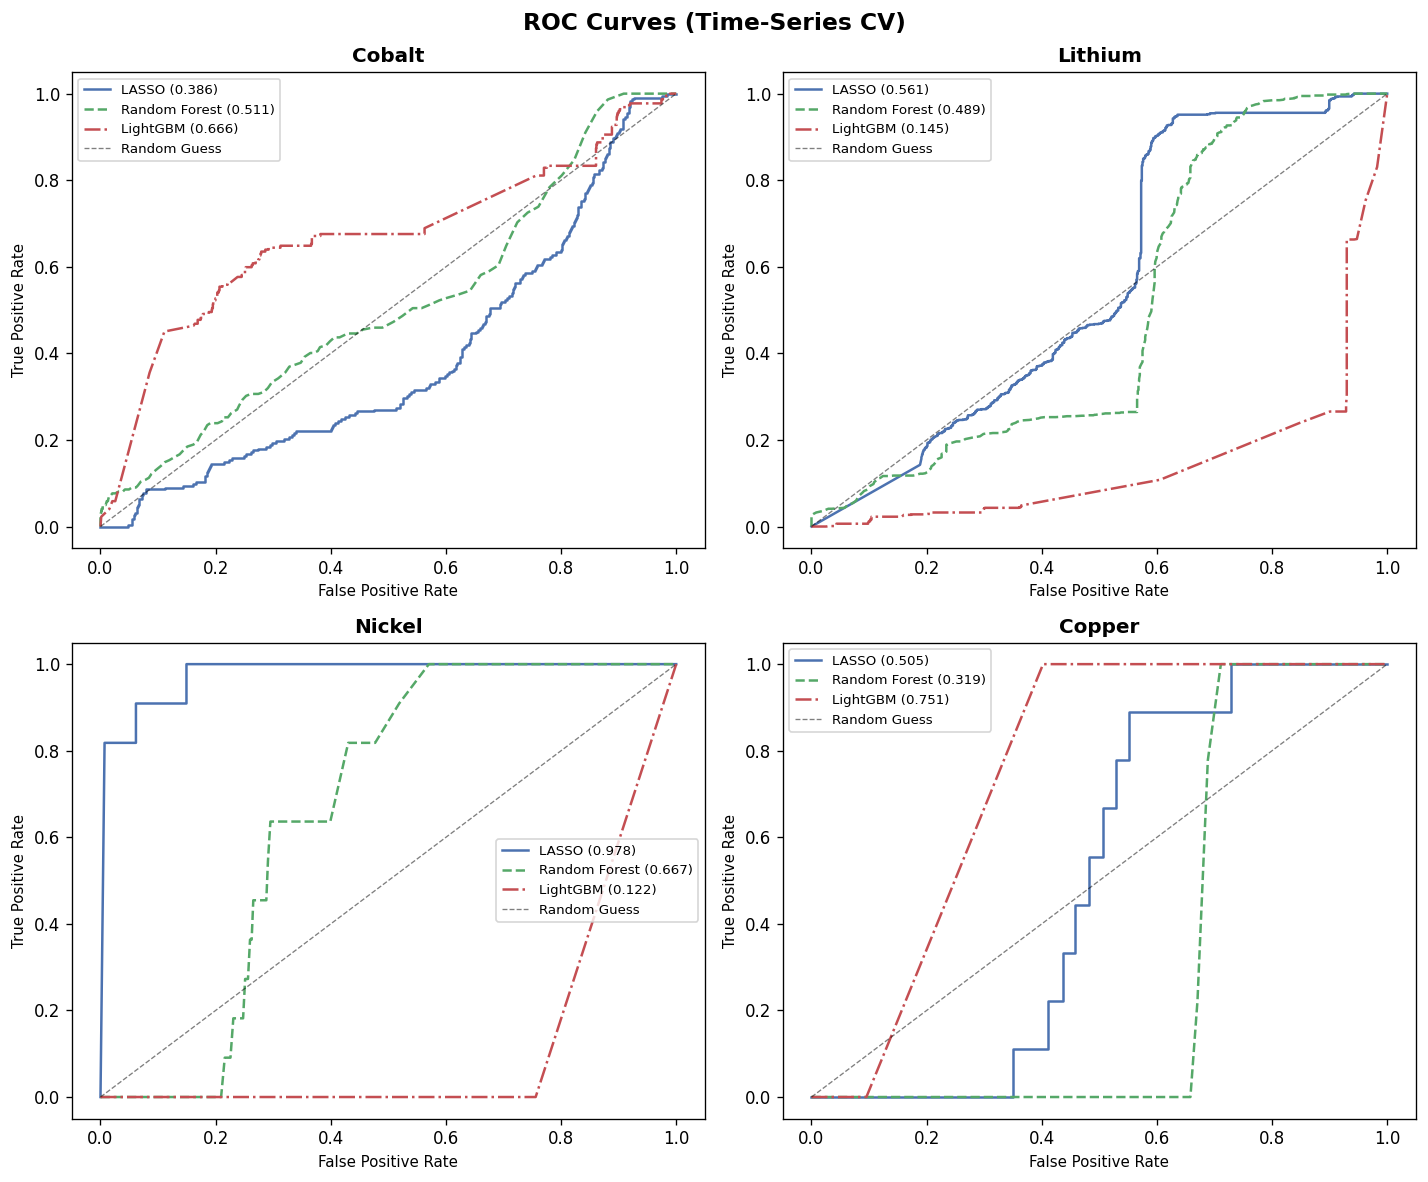

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = {'LASSO': '#4C72B0', 'Random Forest': '#55A868', 'LightGBM': '#C44E52'}
styles = {'LASSO': '-', 'Random Forest': '--', 'LightGBM': '-.'}

for idx, metal in enumerate(metal_configs):
    ax = axes.flat[idx]
    for mname in ['LASSO', 'Random Forest', 'LightGBM']:
        key = (metal, mname)
        if key in cv_preds:
            yt, yp = cv_preds[key]
            fpr, tpr, _ = roc_curve(yt, yp)
            auc_val = roc_auc_score(yt, yp)
            ax.plot(fpr, tpr, color=colors[mname], ls=styles[mname], lw=1.5,
                    label='{} ({:.3f})'.format(mname, auc_val))
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random Guess')
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)

plt.suptitle('ROC Curves (Time-Series CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 10. Feature Importance

- **LightGBM:** SHAP values (TreeSHAP, exact for tree models)
- **LASSO:** Non-zero standardized coefficients
- **Random Forest:** Gini importance (mean decrease in impurity)

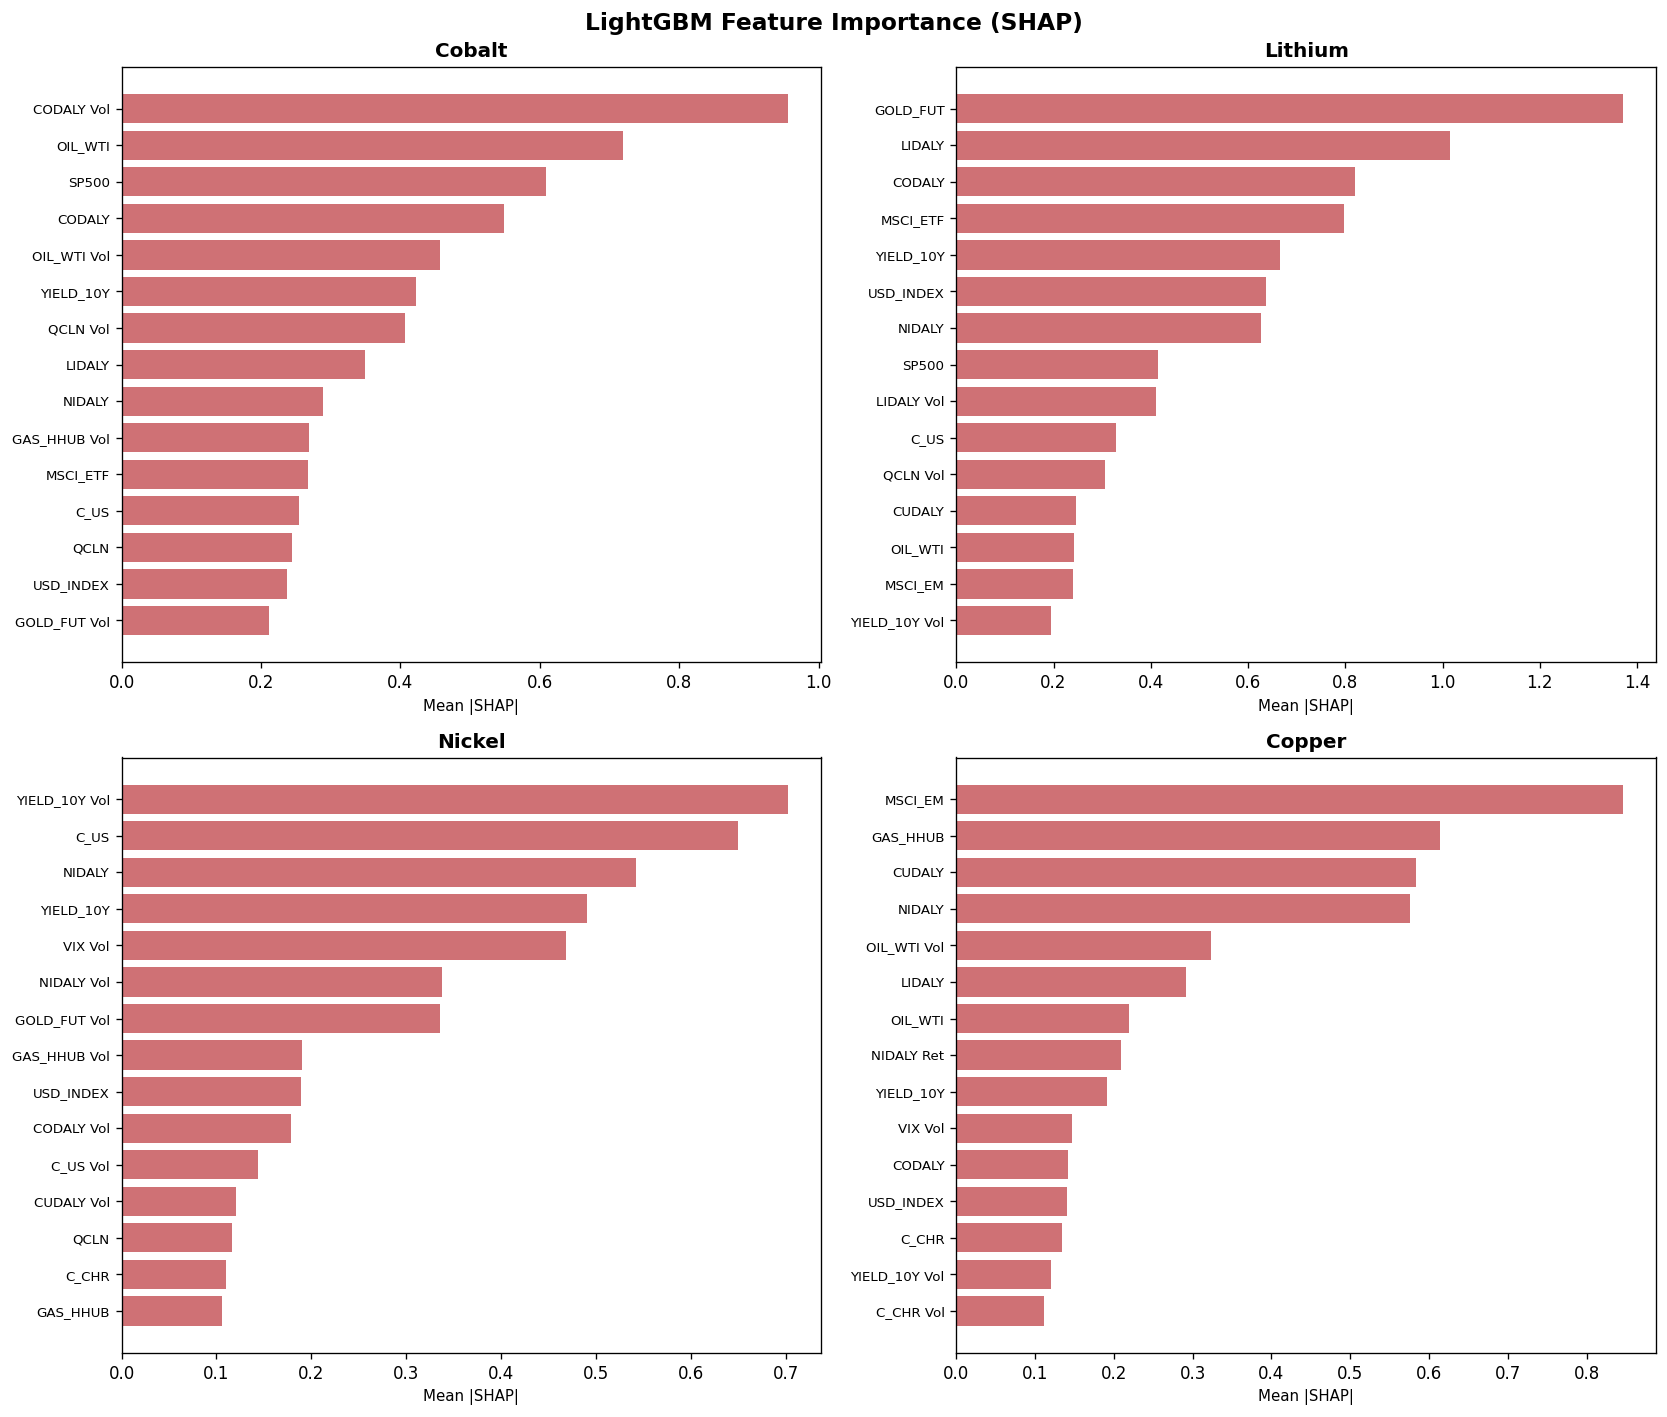

In [11]:
def clean_name(s):
    '''Shorten feature names for plots.'''
    return (s.replace('_Lag1', '').replace('_Level', '')
             .replace('_Ret', ' Ret').replace('_Vol', ' Vol')
             .replace('_BD', ' Bubble'))

# --- LightGBM SHAP ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lgbm_models:
        ax.set_visible(False)
        continue
    info = lgbm_models[metal]
    explainer = shap.TreeExplainer(info['model'])
    np.random.seed(42)
    sample_idx = np.random.choice(len(info['X']), min(500, len(info['X'])), replace=False)
    sv = explainer.shap_values(info['X'][sample_idx])
    if isinstance(sv, list):
        sv = sv[1]

    mean_abs = np.mean(np.abs(sv), axis=0)
    top_k = 15
    top_idx = np.argsort(mean_abs)[-top_k:]
    names = [clean_name(info['features'][i]) for i in top_idx]

    ax.barh(range(top_k), mean_abs[top_idx], color='#C44E52', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=9)

plt.suptitle('LightGBM Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_lgbm.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

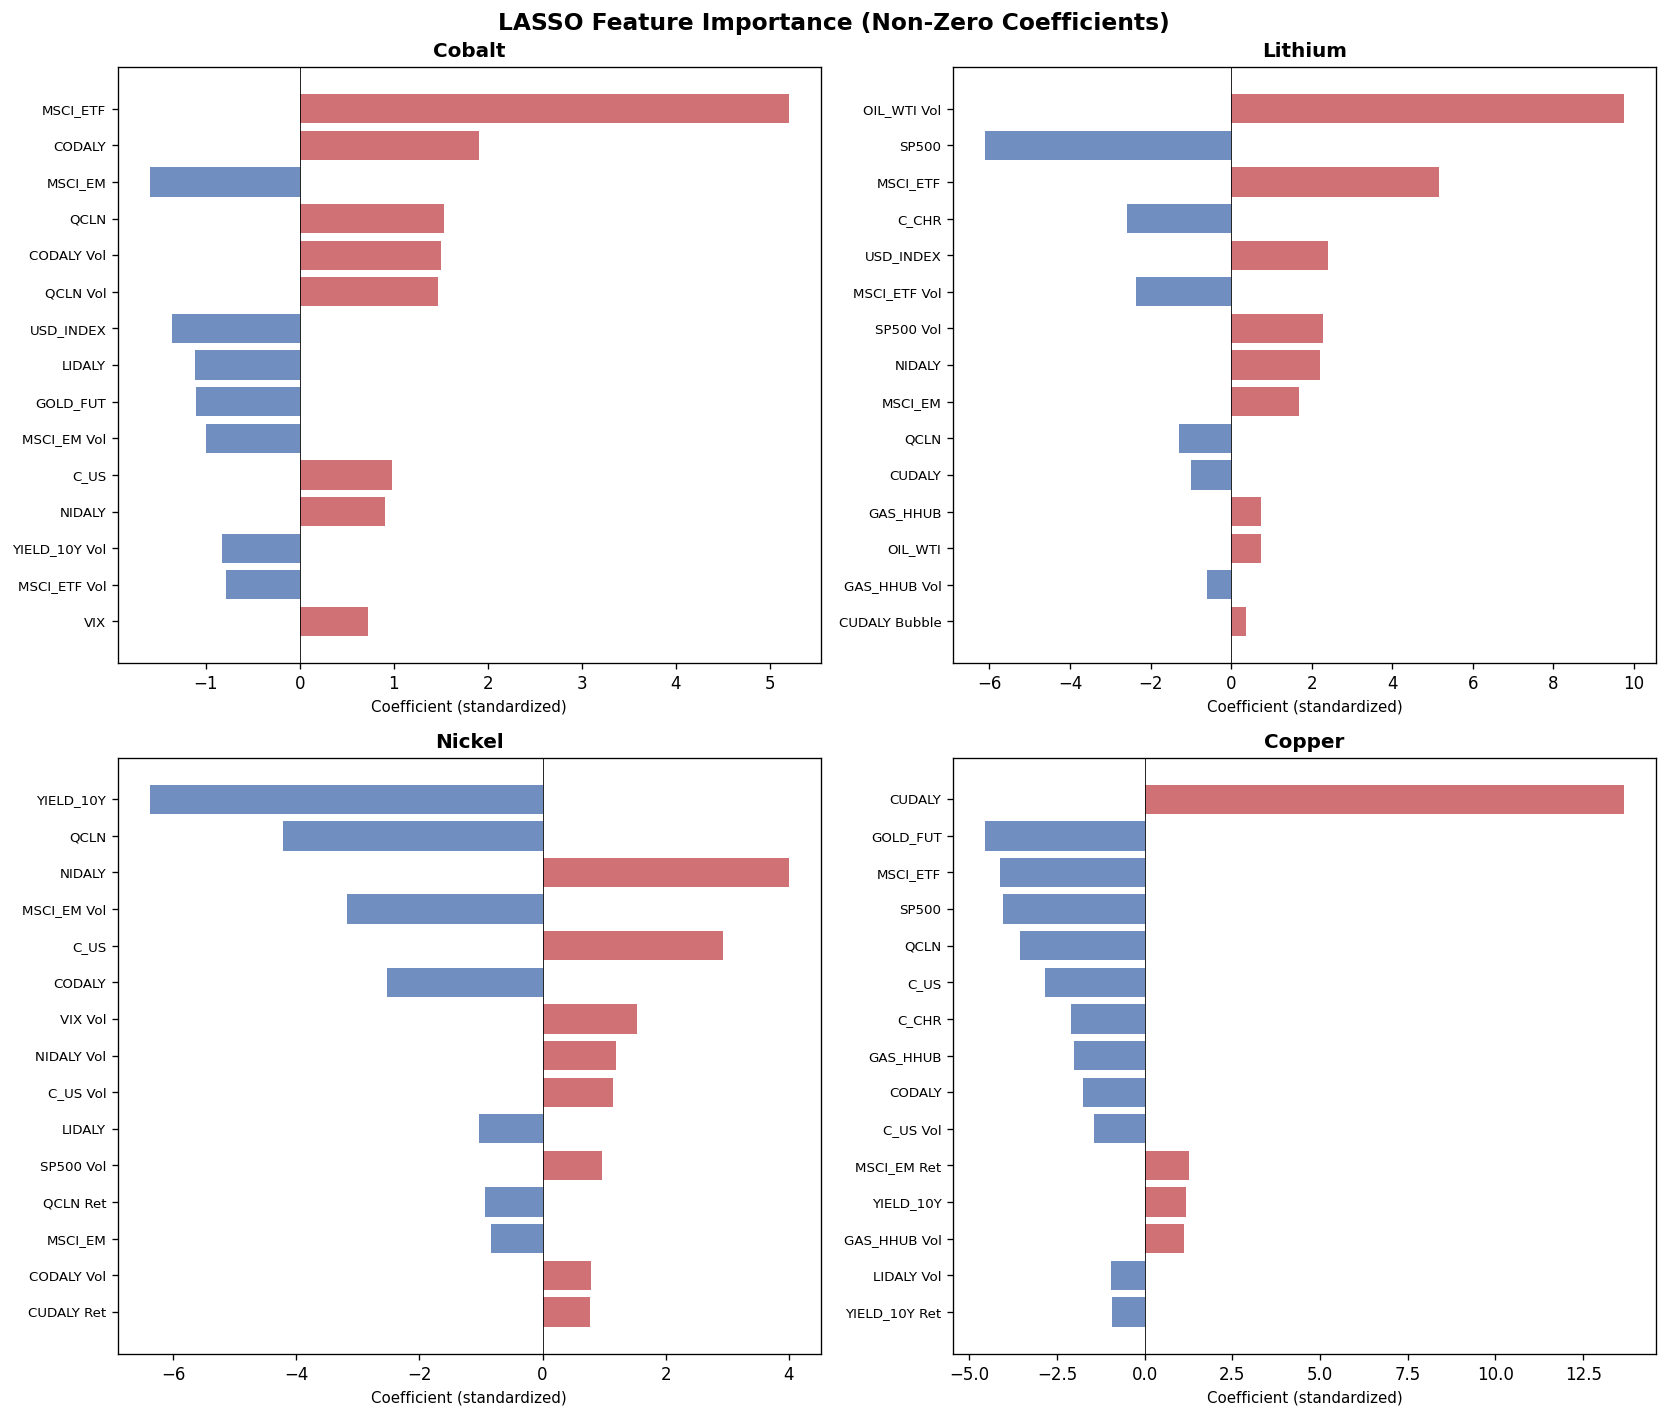

In [12]:
# --- LASSO Coefficients ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in lasso_models:
        ax.set_visible(False)
        continue
    info = lasso_models[metal]
    coefs = info['model'].coef_[0]
    feats = info['features']

    nz_mask = coefs != 0
    if nz_mask.sum() == 0:
        ax.text(0.5, 0.5, 'No features selected', ha='center', va='center',
                transform=ax.transAxes, fontsize=11)
        ax.set_title(metal, fontsize=12, fontweight='bold')
        continue

    nz_coefs = coefs[nz_mask]
    nz_names = [clean_name(feats[i]) for i in range(len(feats)) if nz_mask[i]]

    top_k = min(15, len(nz_coefs))
    order = np.argsort(np.abs(nz_coefs))[-top_k:]
    bar_colors = ['#C44E52' if nz_coefs[j] > 0 else '#4C72B0' for j in order]

    ax.barh(range(top_k), nz_coefs[order], color=bar_colors, alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([nz_names[j] for j in order], fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (standardized)', fontsize=9)
    ax.axvline(0, color='black', lw=0.5)

plt.suptitle('LASSO Feature Importance (Non-Zero Coefficients)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lasso_coefficients.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

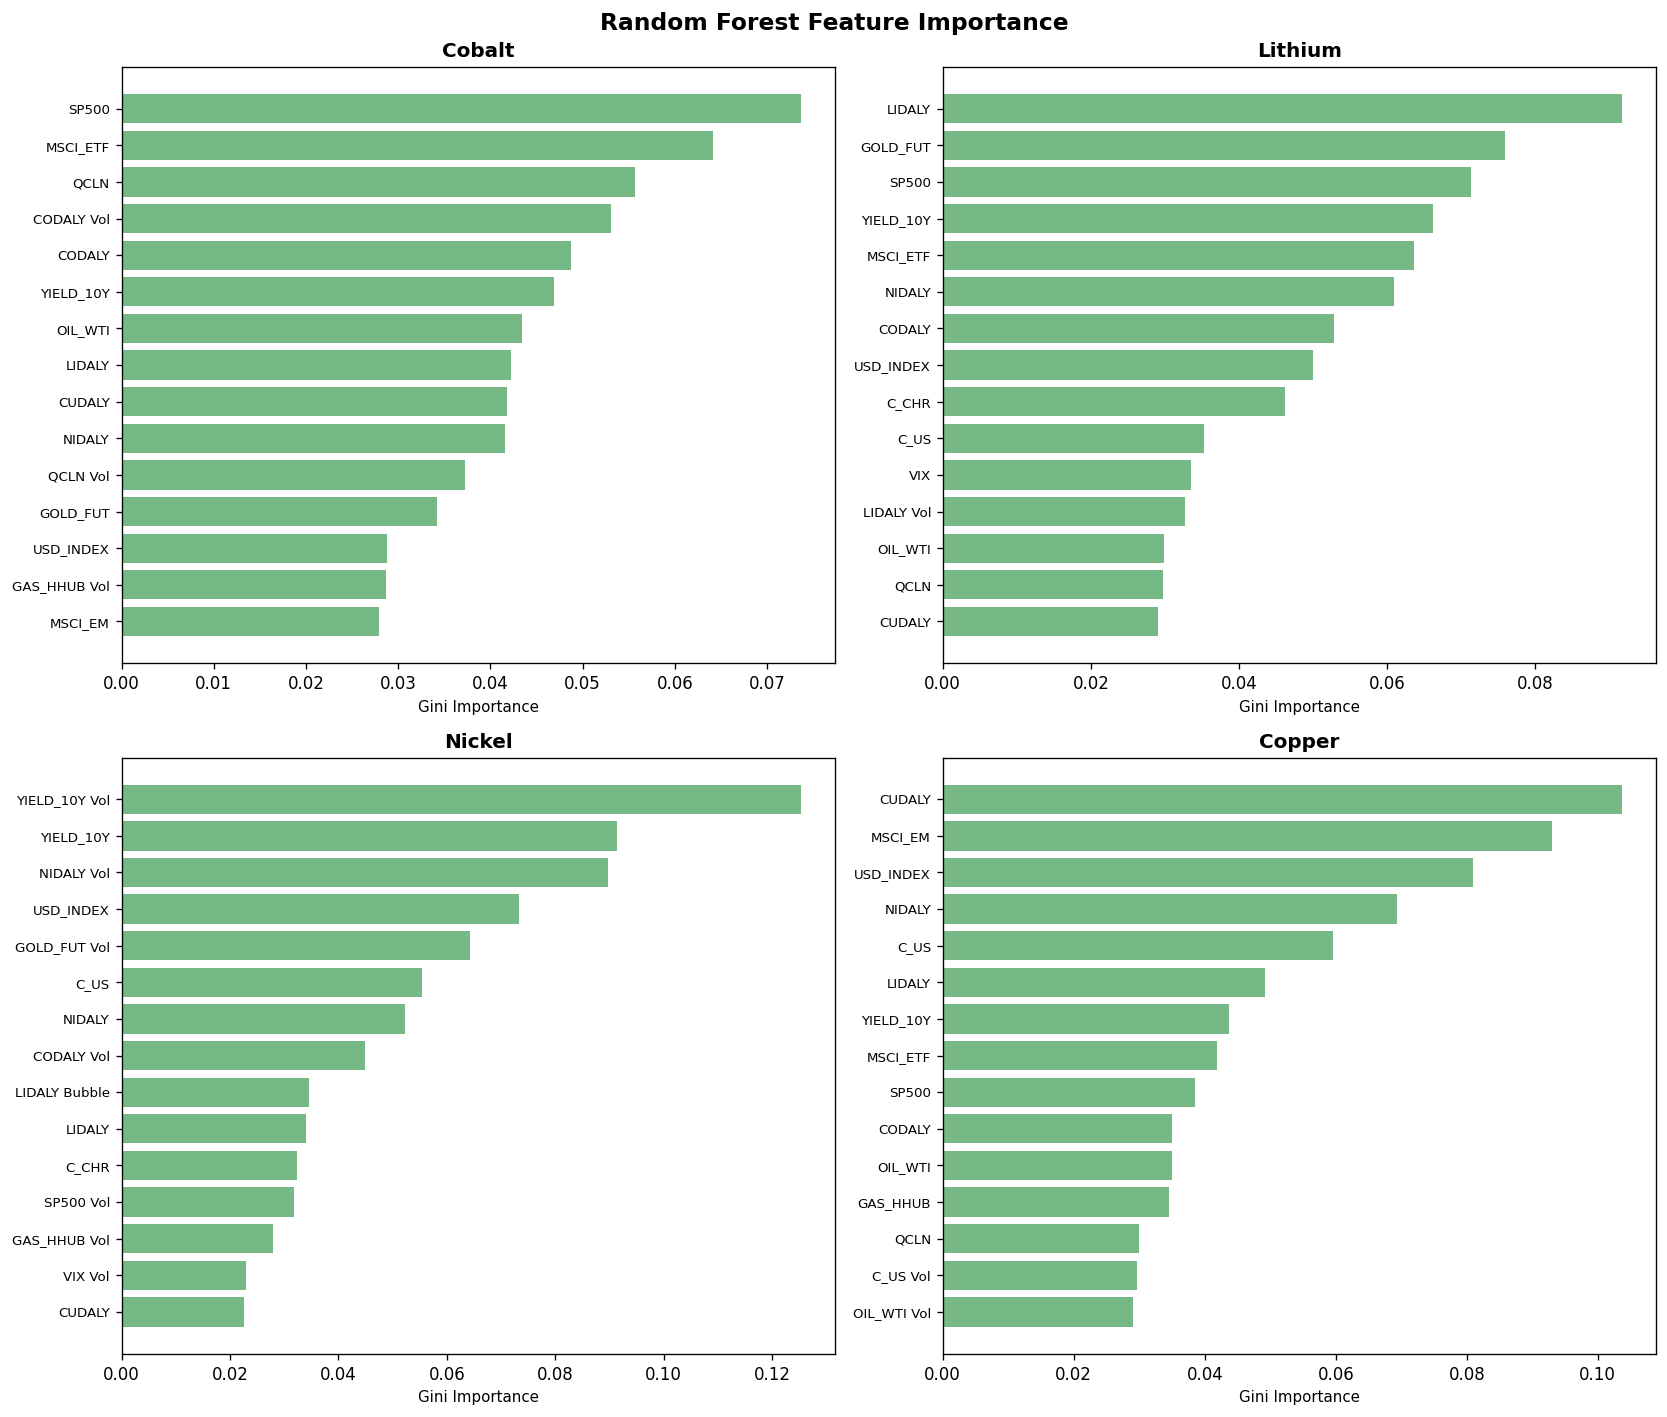

In [13]:
# --- Random Forest Gini Importance ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for idx, (metal, col) in enumerate(metal_configs.items()):
    ax = axes.flat[idx]
    if metal not in rf_models:
        ax.set_visible(False)
        continue
    info = rf_models[metal]
    imp = info['model'].feature_importances_
    top_k = 15
    top_idx = np.argsort(imp)[-top_k:]
    names = [clean_name(info['features'][i]) for i in top_idx]

    ax.barh(range(top_k), imp[top_idx], color='#55A868', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(metal, fontsize=12, fontweight='bold')
    ax.set_xlabel('Gini Importance', fontsize=9)

plt.suptitle('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/rf_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Summary

| Correction | Status |
|---|---|
| Time-series CV (expanding window) | Done -- no future leakage in evaluation |
| Consistent class imbalance handling | Done -- balanced weights for all models |
| Same feature set across models | Done -- fair comparison |
| Early stopping for LightGBM | Done -- temporal validation set per fold |
| VIX series retained | Done -- VIX_Vol included as feature |
| Bubble labels = full-sample GSADF | Kept as ground truth (by design) |

**Outputs saved to `outputs/` folder.**
